In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load the Dataset

df = pd.read_csv("Building_Permits.csv")

In [3]:
# Step 2: Select one categorical column

selected_column = 'Existing Use'

# Step 3: Check missing values

print("Selected Column:", selected_column)

print("\nMissing Values:")
print(df[selected_column].isnull().sum())

print("\nMissing Percentage:")

missing_percentage = (
    df[selected_column].isnull().sum() / len(df)
) * 100

print(round(missing_percentage, 2), "%")


Selected Column: Existing Use

Missing Values:
41114

Missing Percentage:
20.67 %


In [4]:
# Step 4: Find Mode

mode_value = df[selected_column].mode()[0]

print("\nMost Frequent Value / Mode:")
print(mode_value)


Most Frequent Value / Mode:
1 family dwelling


In [5]:
# Approach 1: Mode Imputation

df_mode = df.copy()

df_mode[selected_column] = (
    df_mode[selected_column]
    .fillna(mode_value)
)

In [6]:

# Approach 2: Fill with "Missing"

df_missing = df.copy()

df_missing[selected_column] = (
    df_missing[selected_column]
    .fillna("Missing")
)

In [8]:
# Step 5: Verify Missing Values

print("AFTER MODE IMPUTATION")

print(
    "Missing Values:",
    df_mode[selected_column].isnull().sum()
)


print("AFTER 'MISSING' IMPUTATION")

print(
    "Missing Values:",
    df_missing[selected_column].isnull().sum()
)

AFTER MODE IMPUTATION
Missing Values: 0
AFTER 'MISSING' IMPUTATION
Missing Values: 0


COMPARISON
                      Original (%)  Mode Imputation (%)  \
Existing Use                                              
1 family dwelling        23.512318            44.183007   
apartments               20.511815            20.511815   
office                   12.376068            12.376068   
2 family dwelling        10.551533            10.551533   
retail sales              3.474108             3.474108   
food/beverage hndlng      2.456511             2.456511   
vacant lot                0.911513             0.911513   
tourist hotel/motel       0.837104             0.837104   
residential hotel         0.512821             0.512821   
warehouse,no frnitur      0.437406             0.437406   

                      "Missing" Imputation (%)  
Existing Use                                    
1 family dwelling                    23.512318  
apartments                           20.511815  
office                               12.376068  
2 family dwelling                  

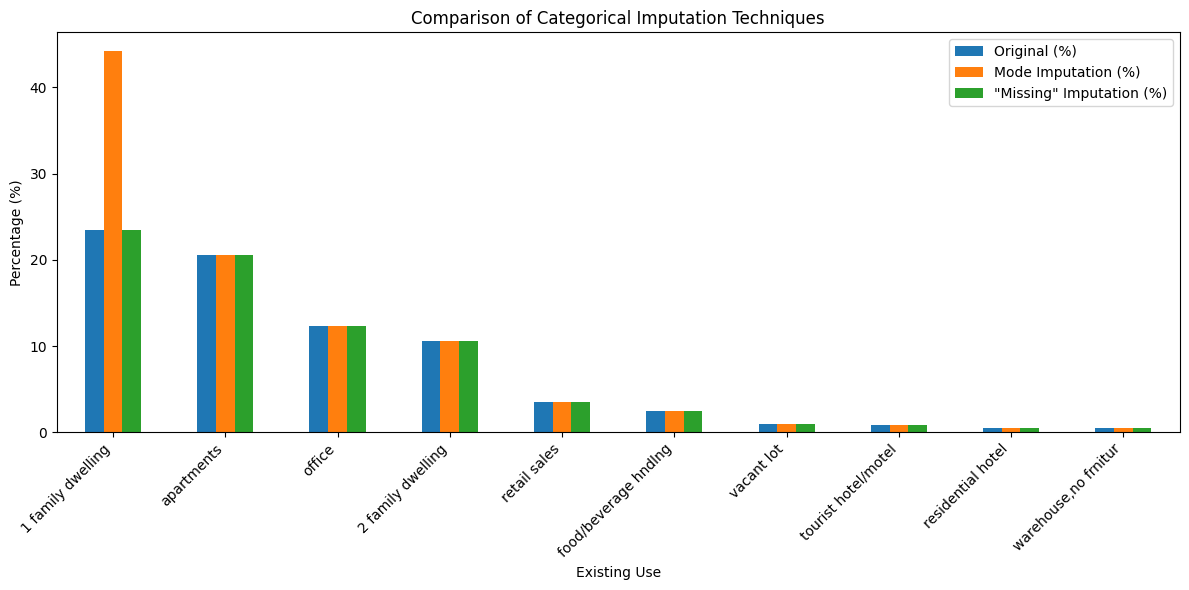

In [10]:
# Step 6: Compare Category Ratios

# Original
original_ratio = (
    df[selected_column]
    .value_counts(normalize=True, dropna=False)
    * 100
)

# Mode Imputation
mode_ratio = (
    df_mode[selected_column]
    .value_counts(normalize=True)
    * 100
)

# Missing Label Imputation
missing_ratio = (
    df_missing[selected_column]
    .value_counts(normalize=True)
    * 100
)

# Step 7: Select Top 10 Original Categories

top_categories = (
    df[selected_column]
    .value_counts()
    .head(10)
    .index
)

# Step 8: Create Comparison Table

comparison = pd.DataFrame({

    'Original (%)':
        original_ratio.reindex(top_categories),

    'Mode Imputation (%)':
        mode_ratio.reindex(top_categories),

    '"Missing" Imputation (%)':
        missing_ratio.reindex(top_categories)

})


print("COMPARISON")
print(comparison)

# Step 9: Visual Comparison

comparison.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title(
    "Comparison of Categorical Imputation Techniques"
)

plt.xlabel(selected_column)
plt.ylabel("Percentage (%)")

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()